# Dummy Classifer

This notebook aims to build dummy classifier from `sklearn` library, evaluate results without SMOTE implement SMOTE, and evaluate results. From this notebook onwards, we shall be using industry standard MLFlow to log all experiments. After reading many articles, I would say MLFlow would be a more useful skill to acquire than WanDB, since it is deeply integrated with industry-leading cloud and data platforms, such as Databricks, Azure, AWS. Learning MLFlow allows me to equip skills like easy experiment tracking, logging, registry and deployment of ML models. Widely used across enterprises, it can help me more in my job search compared to WandB.


## 0. Import Libraries


In [1]:
# Data Analysis Libraries
import pandas as pd 
import numpy as np 
from IPython.display import HTML, display 

# Data Visualization Libraries 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Machine Learning Libraries
from sklearn.dummy import DummyClassifier

# Data Preparation and Evaluation Libraries
import src.data_preprocess as dp
import src.evaluation as ev

print(f"Current pandas version: {pd.__version__}")

Current pandas version: 2.0.3


In [ ]:
# - MLFlow Logging - 
import mlflow 

# - Current Notebook: Runs is under Dummy Classifier Experiment - 
def set_or_create_experiment(name: str):
    exp = mlflow.get_experiment_by_name(name)
    if exp is None:
        mlflow.create_experiment(name)
        print(f"✅ Experiment '{name}' created.")
    
    mlflow.set_experiment(name)
    print(f"✅ Current experiment set to '{name}'.")
    
set_or_create_experiment("Dummy Classifier Experiment")

## 1. Read & Standardise Data


In [3]:
df1 = pd.read_csv('data/processed/creditcard_cleaned.csv')
df1.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# - Apply Train Test Split -
X_train, X_val, X_test, y_train, y_val, y_test = dp.train_val_test_split(df1, target_column='Class')

Initial Dataset shape: (283726, 30)
-----------------------------
X_train shape: (170235, 30) Pct: 60.0%
y_train shape: (170235,)
-----------------------------
X_val shape: (56745, 30) Pct: 20.0%
y_val shape: (56745,)
-----------------------------
X_test shape: (56746, 30) Pct: 20.0%
y_test shape: (56746,)


In [5]:
# - Visualise unstandardized features distribution -
display(X_train.head(), X_test.head())

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
102732,68504.0,-1.466684,0.437843,1.798819,-1.955137,-1.436692,0.141052,-1.339819,1.163623,-1.273979,...,-0.124413,0.585563,1.189609,-0.368531,-0.323312,0.410506,-0.108637,-0.307629,-0.095969,8.99
267836,163410.0,2.099619,-0.023369,-1.369803,0.224338,0.339848,-0.669249,0.224435,-0.315935,0.446580,...,-0.136091,-0.319857,-0.739342,0.237677,-0.748881,-0.181017,0.244591,-0.063086,-0.065425,5.99
2183,1719.0,-1.960524,1.438062,-0.067457,-0.382996,0.369982,-0.113959,0.181212,0.504365,0.062941,...,0.029317,-0.448709,-0.847225,0.241987,-1.030383,0.234938,0.156216,0.338689,0.100345,16.00
176562,123093.0,1.838230,-0.641136,-0.425984,0.560873,-0.835237,0.005472,-1.102837,0.245831,1.666006,...,-0.030587,0.150565,0.399034,0.188064,0.483990,-0.557038,0.485454,0.003685,0.010003,75.34
226443,145015.0,0.751899,-2.034001,-1.388385,1.703266,-0.369474,0.535422,0.645324,-0.170321,0.656970,...,1.167378,-0.014687,-1.277865,-0.182382,0.156963,-0.475163,-1.138433,-0.064637,0.087829,648.84


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
86249,61290.0,1.228821,-0.063408,0.274145,0.647465,-0.048135,0.372073,-0.224231,0.079939,0.640759,...,-0.096566,-0.129554,-0.083779,-0.151661,-0.700372,0.598550,0.491409,0.002989,0.001782,11.50
250634,155394.0,-0.203154,1.176678,-0.759595,-0.518472,0.629649,-0.721675,0.638893,0.243377,-0.157488,...,-0.098429,0.384629,1.206754,-0.082753,0.508386,-0.710906,-0.234510,0.379640,0.261351,1.94
20163,30881.0,-1.672836,1.401297,1.503940,2.175491,0.699791,1.062139,1.114364,-0.535822,-0.252983,...,0.828472,-0.525950,-0.408743,-0.280083,-0.846468,-0.155456,-0.062383,0.007777,0.113900,91.28
68688,53203.0,0.819379,-1.124913,0.515025,0.513945,-1.009048,0.488484,-0.580672,0.187686,-0.999142,...,-0.110144,-0.057205,-0.168061,-0.198732,-0.337408,0.238538,-0.289454,0.038214,0.058407,228.00
191151,129429.0,2.009701,0.105635,-1.752759,0.588312,0.374801,-0.637884,0.009260,-0.129487,0.492619,...,-0.135479,0.008970,0.357394,-0.013472,-0.446920,0.111522,0.642944,-0.036998,-0.043404,1.41


In [6]:
# - Scaling of Features - 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

display(X_train_scaled.describe(), X_test_scaled.describe())


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,...,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05,1.702350e+05
mean,8.932132e-17,2.637901e-17,-1.060169e-17,1.030952e-17,-1.552688e-17,-1.260516e-17,2.170425e-18,-1.352341e-17,3.172159e-18,7.513008e-18,...,7.846920e-18,-1.669557e-18,1.101908e-17,-3.297376e-18,-3.145029e-17,-2.337380e-18,-1.602775e-17,-6.302579e-18,-3.589548e-18,7.713355e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,...,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-1.998089e+00,-2.890460e+01,-4.385165e+01,-2.115123e+01,-3.948438e+00,-2.357710e+01,-1.976563e+01,-3.463469e+01,-6.269327e+01,-1.226384e+01,...,-3.085285e+01,-4.822267e+01,-1.512209e+01,-7.196027e+01,-4.679219e+00,-1.971052e+01,-5.411684e+00,-5.726023e+01,-3.516209e+01,-3.577232e-01
25%,-8.572931e-01,-4.714192e-01,-3.585194e-01,-5.906398e-01,-5.976386e-01,-5.102166e-01,-5.789135e-01,-4.636778e-01,-1.791937e-01,-5.877955e-01,...,-2.762023e-01,-3.183692e-01,-7.488514e-01,-2.639275e-01,-5.855511e-01,-6.105171e-01,-6.791548e-01,-1.827592e-01,-1.605461e-01,-3.346759e-01
50%,-2.098539e-01,7.004965e-03,4.175699e-02,1.155985e-01,-1.451939e-02,-4.247452e-02,-2.062127e-01,3.217413e-02,1.883438e-02,-4.601050e-02,...,-8.114761e-02,-4.244436e-02,1.069129e-02,-2.122442e-02,6.792648e-02,3.009123e-02,-1.082681e-01,-2.096535e-04,3.246766e-02,-2.682930e-01
75%,9.345406e-01,6.717175e-01,4.854011e-01,6.821729e-01,5.245662e-01,4.475205e-01,3.036905e-01,4.749735e-01,2.785386e-01,5.453091e-01,...,1.742499e-01,2.560106e-01,7.291303e-01,2.354969e-01,7.269346e-01,6.716726e-01,4.982311e-01,2.268882e-01,2.330045e-01,-4.295246e-02
max,1.638532e+00,1.255593e+00,1.295009e+01,6.234214e+00,1.190102e+01,2.555992e+01,1.616643e+01,2.861917e+01,1.677149e+01,1.423682e+01,...,5.143609e+01,3.130516e+01,1.452616e+01,3.617607e+01,6.630274e+00,1.439292e+01,7.307421e+00,3.083059e+01,1.016220e+02,7.940123e+01


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
count,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,...,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000,56746.000000
mean,-0.010131,0.002581,0.004129,-0.003216,-0.003782,-0.011545,0.003190,0.000074,-0.003654,0.003375,...,-0.001270,-0.011605,-0.001074,0.000359,0.003574,-0.006030,-0.001356,0.001380,-0.004812,0.002655
std,0.998690,0.999646,0.986068,1.006660,0.989381,1.060935,1.031806,1.111341,1.042183,1.005303,...,1.057559,1.011280,1.003147,0.988684,0.998228,0.994616,1.007068,1.054934,1.011743,1.087979
min,-1.998046,-19.246442,-23.098725,-32.127700,-3.818481,-83.554194,-16.568485,-27.736527,-43.403192,-9.898022,...,-71.106072,-31.691372,-9.828792,-58.885307,-4.563715,-12.851976,-3.564847,-25.111305,-46.328475,-0.357723
25%,-0.860324,-0.471897,-0.357181,-0.599417,-0.601240,-0.511783,-0.580044,-0.463493,-0.180315,-0.587745,...,-0.274317,-0.320657,-0.757046,-0.258112,-0.580323,-0.608087,-0.680836,-0.184093,-0.162256,-0.335447
50%,-0.220272,0.012604,0.042123,0.121016,-0.015413,-0.046402,-0.204596,0.031624,0.016924,-0.044569,...,-0.081297,-0.048313,0.005157,-0.018659,0.069111,0.030175,-0.113025,-0.000475,0.029977,-0.270139
75%,0.928142,0.673532,0.483461,0.679061,0.517604,0.437107,0.298966,0.468669,0.278980,0.551086,...,0.173001,0.251239,0.727034,0.232009,0.725397,0.666177,0.501125,0.225552,0.227840,-0.047325
max,1.638490,1.243079,10.073677,2.606231,10.793076,24.171464,55.389165,100.614222,13.523153,9.487812,...,31.490066,27.773390,11.440680,30.514456,7.567990,9.202330,7.195020,80.206288,47.636122,103.887534


In [7]:
dp.check_scaling_validity(X_train_scaled)
dp.check_scaling_validity(X_test_scaled)

✅ Feature means after scaling:
 Time      8.932132e-17
V1        2.637901e-17
V2       -1.060169e-17
V3        1.030952e-17
V4       -1.552688e-17
V5       -1.260516e-17
V6        2.170425e-18
V7       -1.352341e-17
V8        3.172159e-18
V9        7.513008e-18
V10       1.094604e-17
V11       1.243820e-17
V12       1.035126e-17
V13       2.045208e-17
V14      -2.170425e-18
V15      -1.477558e-17
V16       1.844861e-17
V17      -2.120338e-17
V18       6.886924e-18
V19       1.419124e-17
V20       7.846920e-18
V21      -1.669557e-18
V22       1.101908e-17
V23      -3.297376e-18
V24      -3.145029e-17
V25      -2.337380e-18
V26      -1.602775e-17
V27      -6.302579e-18
V28      -3.589548e-18
Amount    7.713355e-17
dtype: float64
-----------------------------------

✅ Feature std devs after scaling:
 Time      1.000003
V1        1.000003
V2        1.000003
V3        1.000003
V4        1.000003
V5        1.000003
V6        1.000003
V7        1.000003
V8        1.000003
V9        1.000003
V

As observed, all scaling worked correctly since scaling should place features of different scales to the same scale where mean is near 0 and standard deviation is 1. We can proceed to the next step.


## 2. Dummy Classifier (Most Frequent) Model Building

To check effect of SMOTE, lets first train a dummy classifier which relies on random guessing. For imbalanced datasets, we can use `most_frequent` method since it simply guesses the most frequently appearing label (non-fraud). This label is often used for extremely imbalanced datasets.


In [8]:
# - Check Class Distribution - 
print("✅ Training Set Class Distribution:", y_train.value_counts())
print("\n------------------------------")

print("✅ Test Set Class Distribution:", y_test.value_counts())

✅ Training Set Class Distribution: Class
0    169951
1       284
Name: count, dtype: int64

------------------------------
✅ Test Set Class Distribution: Class
0    56651
1       95
Name: count, dtype: int64


In [9]:
# - Instantiate and Train Dummy Classifier - 
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,42
,constant,None


In [10]:
# - Make predictions on the test data - 
y_pred = dummy.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

✅ Model Results Analysis
Accuracy:  0.9983
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

✅ Classification Report:
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9992     56651
           1     0.0000    0.0000    0.0000        95

    accuracy                         0.9983     56746
   macro avg     0.4992    0.5000    0.4996     56746
weighted avg     0.9967    0.9983    0.9975     56746

--------------------

✅ Confusion Matrix:


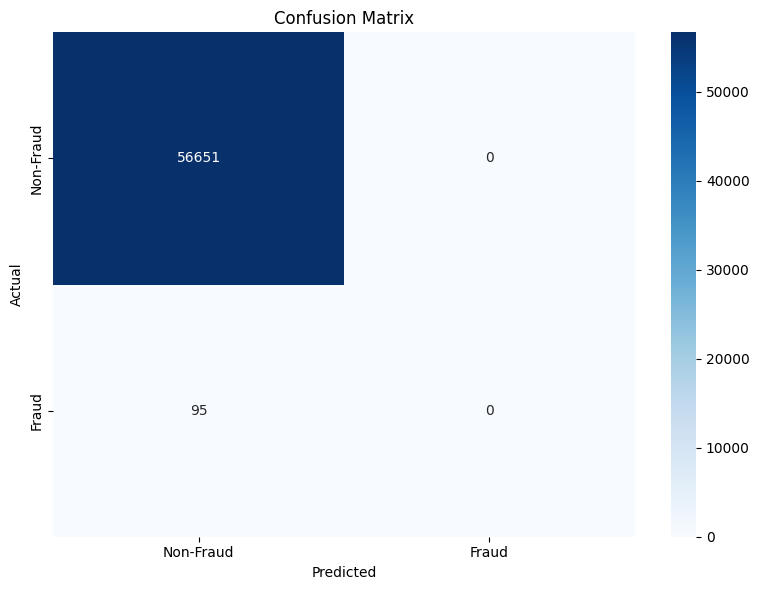

In [11]:
# - Analyze Dummy Classifier Results -
analyzer = ev.ResultsAnalyser()
dummy_metrics = analyzer.analyze_predictions(
    y_true=y_test, 
    y_pred=y_pred, 
    class_labels=['Non-Fraud', 'Fraud']
)

| **Metric**                        | **Why it matters**                                   | **What to compare**                                                         |
| --------------------------------- | ---------------------------------------------------- | --------------------------------------------------------------------------- |
| **Recall for fraud (class 1)**    | Shows how many actual fraud cases the model catches. | Models built should have **recall > 0** for fraud (baseline = 0) (no SMOTE) |
| **Precision for fraud (class 1)** | Shows how many predicted frauds are correct.         | Higher than 0 means it’s catching real frauds.                              |
| **F1-score for fraud (class 1)**  | Balances recall and precision.                       | Any F1 > 0 beats the baseline.                                              |


## 3. SMOTE Application

Now, lets observe the effectiveness of applying SMOTE to our training data. SMOTE is one of the most famous techniques to address class imbalance. To put it simply, imagine plotting of all data points in a feature space. The SMOTE algorithm will randomly select 1 data point from the minority class and find its k nearest neighbors from minority class (default k = 5). It randomly selects 1 of the neighbors, draws a line between this point and the data point aforementioned. It then creates a **new synthetic data point** on this line. The algorithm repeats until **a desired number of synthetic data points** is reached.

This reduces overfitting of our ML models to the majority class and improves model performance in real life (since we are aiming for our built ML models to see patterns in the minority class, while not raising too many false alarms).


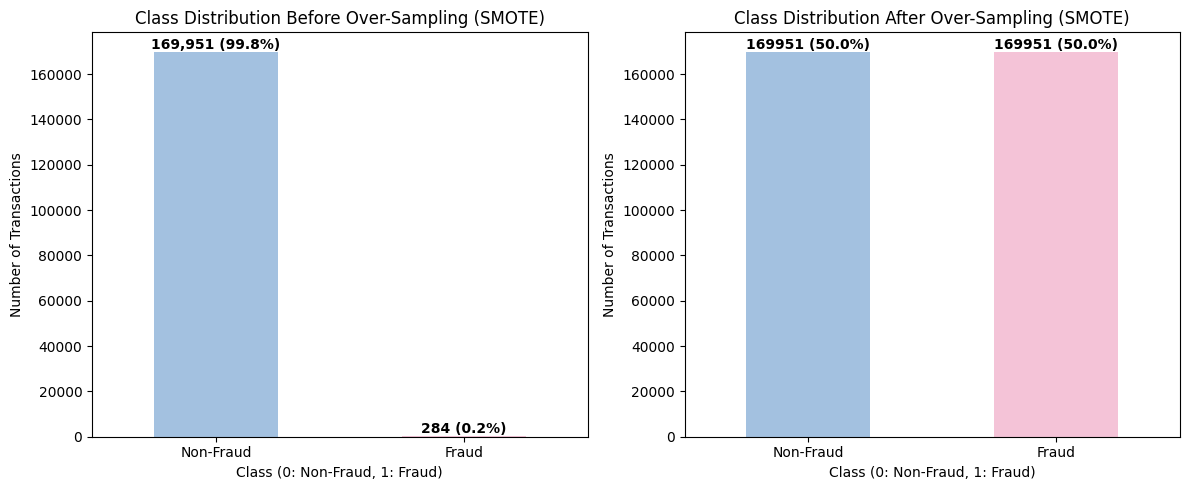

In [12]:
# - Apply SMOTE using ApplySmote class -
smote_balancer = dp.ApplySmote(random_state=42)
X_train_smote, y_train_smote = smote_balancer.fit_resample(X_train_scaled, y_train)

## 4. Dummy Classifier (Uniform) with SMOTE

Now let's test a `uniform` strategy dummy classifier with the SMOTE-balanced data. The uniform strategy provides a more realistic baseline since it randomly predicts each class with equal probability, giving us meaningful recall and precision baselines to compare against real models.


✅ Model Results Analysis
Accuracy:  0.5011
Precision: 0.0014
Recall:    0.4105
F1-Score:  0.0027

✅ Classification Report:
              precision    recall  f1-score   support

           0     0.9980    0.5012    0.6673     56651
           1     0.0014    0.4105    0.0027        95

    accuracy                         0.5011     56746
   macro avg     0.4997    0.4559    0.3350     56746
weighted avg     0.9964    0.5011    0.6662     56746

--------------------

✅ Confusion Matrix:


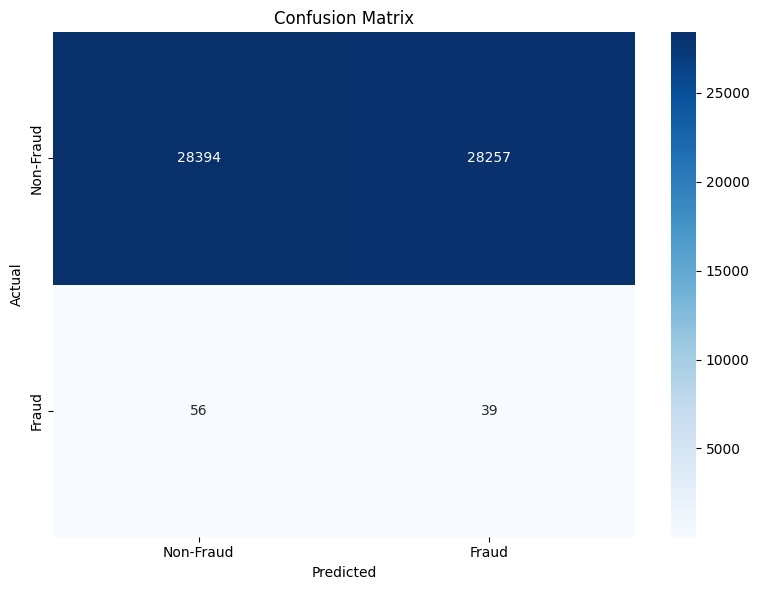

In [13]:
# - Train Dummy Classifier with SMOTE Data -
dummy_smote = DummyClassifier(strategy='uniform', random_state=42)
dummy_smote.fit(X_train_smote, y_train_smote)

# - Make predictions -
y_pred_smote = dummy_smote.predict(X_test_scaled)

# - Analyze Results -
analyzer_smote = ev.ResultsAnalyser()
smote_metrics = analyzer_smote.analyze_predictions(
    y_true=y_test, 
    y_pred=y_pred_smote, 
    class_labels=['Non-Fraud', 'Fraud']
)

In [14]:
# - Compare Results -
print("✅ Dummy Classifier Comparison")
print("=" * 40)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Most Frequent': [
        dummy_metrics['accuracy'],
        dummy_metrics['precision'], 
        dummy_metrics['recall'],
        dummy_metrics['f1_score']
    ],
    'Uniform (With SMOTE)': [
        smote_metrics['accuracy'],
        smote_metrics['precision'],
        smote_metrics['recall'], 
        smote_metrics['f1_score']
    ]
}).round(4)

display(comparison_df)


✅ Dummy Classifier Comparison


,Metric,Most Frequent,Uniform (With SMOTE)
0,Accuracy,0.9983,0.5011
1,Precision,0.0000,0.0014
2,Recall,0.0000,0.4105
3,F1-Score,0.0000,0.0027


## Summary

In this notebook, we successfully established baseline performance using dummy classifiers

- **Dummy Classifier Issues**:

  - **Extremely Low Precision (Fraud Class)**: Predicts too many fraudulent cases when they are not
  - **Unsatisfactory Recall (Fraud Class)**: Catches unsatisfactory number of fraudulent cases amongst true fraudulent transactions
  - **Near-to-Perfect Precision (Non-Fraud Class)**: Correctly catches almost all non-fraudulent cases amongst its non-fraudlent predictions
  - **Unsatisfactory Recall (Non-Fraud Class)**: Out of all true non-fraud transactions, only predicts ~50% non-fraud transactions

- **Established meaningful baselines**: Uniform strategy provides realistic targets for real models
- **Demonstrated SMOTE effect**: Balanced classes from 284:169,951 to 1:1 ratio

### Baseline Results (Important: Fraud Class)

| Strategy             | Accuracy   | Precision | Recall     | F1-Score  |
| -------------------- | ---------- | --------- | ---------- | --------- |
| Most Frequent        | 99.83%     | 0.00%     | 0.00%      | 0.00%     |
| **Uniform (Target)** | **50.11%** | **0.14%** | **41.05%** | **0.27%** |

### Next Steps

- Build LightGBM, XGBoost, ANN, QML models etc
- Target: **Recall > 41%** and **Precision > 0.14%** on Fraud Class
- Use `ApplySmote` class for consistent SMOTE application
- Implement MLflow experiment tracking for all models
